In [5]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_monthly_summary.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_yearly_performance.csv
/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [7]:
file_path = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (33364, 15)


,coin_id,coin_name,symbol,market_cap_rank,timestamp,date,price,market_cap,volume,daily_return,price_ma7,price_ma30,volatility_7d,cumulative_return,month
0,aave,Aave,AAVE,46,2024-12-04 00:00:00,2024-12-04,241.886714,3.633154e+09,1.181708e+09,NaN,241.886714,241.886714,NaN,NaN,2024-12
1,aave,Aave,AAVE,46,2024-12-05 00:00:00,2024-12-05,255.966610,3.841768e+09,1.191179e+09,5.820864,248.926662,248.926662,NaN,5.820864,2024-12
2,aave,Aave,AAVE,46,2024-12-06 00:00:00,2024-12-06,248.589404,3.725870e+09,8.706666e+08,-2.882097,248.814243,248.814243,6.153922,2.771004,2024-12
3,aave,Aave,AAVE,46,2024-12-07 00:00:00,2024-12-07,281.755167,4.226339e+09,1.120551e+09,13.341583,257.049474,257.049474,8.119016,16.482283,2024-12
4,aave,Aave,AAVE,46,2024-12-08 00:00:00,2024-12-08,282.398618,4.241226e+09,6.553344e+08,0.228372,262.119303,262.119303,7.120498,16.748297,2024-12


Model Metrics:


,Metric,Value
0,MAE,33.456910
1,RMSE,127.747056
2,R2,0.999962


Feature Importance:


,Feature,Importance
0,price_ma7,5.586978e-01
1,price_ma30,4.287269e-01
2,cumulative_return,1.256903e-02
3,daily_return,2.586149e-06
4,volatility_7d,1.465567e-06
5,market_cap,1.435197e-06
6,volume,5.934291e-07
7,market_cap_rank,1.924520e-07


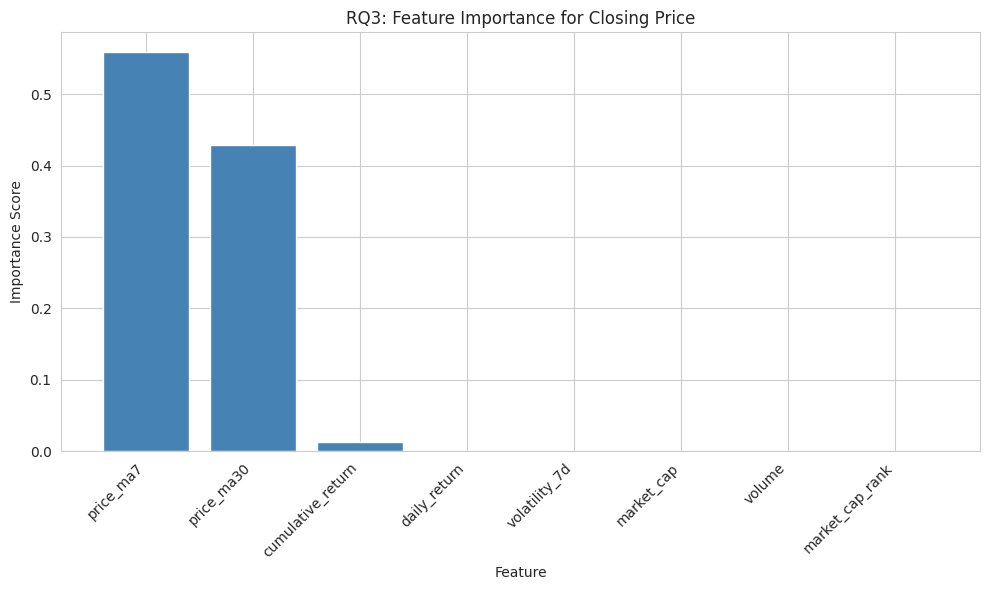

In [9]:
# RQ3: Which available features most significantly influence the closing price?

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "/kaggle/input/datasets/mihikaajayjadhav/top-100-cryptocurrencies-daily-price-data-2025/crypto_historical_365days.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

# Sort data
df = df.sort_values(["coin_id", "date"]).reset_index(drop=True)

# Target variable: closing price proxy in this dataset
target_col = "price"

# Available predictor features
feature_cols = [
    "market_cap_rank",
    "market_cap",
    "volume",
    "daily_return",
    "price_ma7",
    "price_ma30",
    "volatility_7d",
    "cumulative_return"
]

model_df = df[["date", target_col] + feature_cols].copy()

# Time-based split
unique_dates = sorted(model_df["date"].unique())
split_index = int(len(unique_dates) * 0.80)

train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

train_df = model_df[model_df["date"].isin(train_dates)].copy()
test_df = model_df[model_df["date"].isin(test_dates)].copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df[target_col]
y_test = test_df[target_col]

# Train regression model
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Model metrics table
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [
        mean_absolute_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred) ** 0.5,
        r2_score(y_test, y_pred)
    ]
})

metrics_df.to_csv("/kaggle/working/RQ3_model_metrics.csv", index=False)

# Feature importance table
importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

importance_df.to_csv("/kaggle/working/RQ3_feature_importance.csv", index=False)

print("Model Metrics:")
display(metrics_df)

print("Feature Importance:")
display(importance_df)

# Figure
plt.figure(figsize=(10, 6))
plt.bar(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.title("RQ3: Feature Importance for Closing Price")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/RQ3_feature_importance.pdf")
plt.show()
